In [2]:
import pandas as pd
#import pyarrow as pa
#import pyarrow.parquet as pq
from fuzzywuzzy import fuzz
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

C:\Users\fedew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


## EJERCICIO CLASE TEORICA 22/05

In [3]:
datos = pd.read_csv("datasets/advertising.csv")
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Ejercicio 1
Calcula la matriz de correlaciones lineales entre todas las variables del dataset. Que predictories parecen estar mas asociados con sales?

In [9]:
matriz_corr = datos.corr().round(2)
matriz_corr

,TV,Radio,Newspaper,Sales
TV,1.00,0.05,0.06,0.90
Radio,0.05,1.00,0.35,0.35
Newspaper,0.06,0.35,1.00,0.16
Sales,0.90,0.35,0.16,1.00


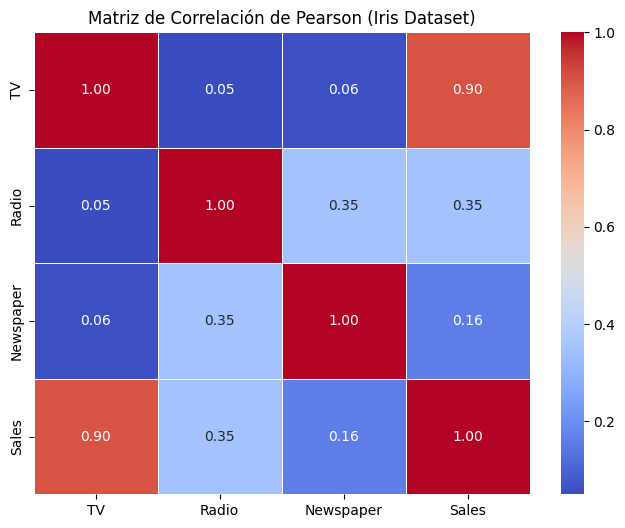

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, 
            annot=True,       # Muestra el número dentro de cada celda
            cmap='coolwarm',  # Escala de colores (Rojo=Positivo, Azul=Negativo)
            fmt=".2f",        # Limita a 2 decimales
            linewidths=0.5)   # Agrega una pequeña línea divisoria entre celdas

plt.title('Matriz de Correlación de Pearson (Advertising Dataset)')
plt.show()

## Ejercicio 2
Ajusta un modelo de regresion lineal multiple para sales usando los tres predictores: TV, Radio, Newspaper. 
Cuales predictores son estadisticamente significativos al 5%?

In [12]:
modelo1 = smf.ols(formula= 'Sales ~ TV + Radio + Newspaper', data=datos).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                sáb, 30 may 2026   Prob (F-statistic):           8.13e-99
Time:                        19:17:40   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

## Ejercicio 3
Reajusta el modelo eliminando el o los predictores no significativos.

In [11]:
modelo2 = smf.ols(formula= 'Sales ~ TV + Radio', data=datos).fit()  #Ajustamos Modelo Reducido
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                sáb, 30 may 2026   Prob (F-statistic):          2.39e-100
Time:                        19:17:37   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6309      0.290     15.952      0.0

Usando el modelo reducido, estima las ventas esperadas para un mercado con inversion de 150 mil USD en TV, 30 mil USD en Radio y 60 mil USD en periodicos.

Prediccion:

In [ ]:
# el metodo .predict necesita de un objeto de tipo df, por lo tanto armamos uno con, para cada uno los predictores, 
# el valor para el que quiero predecir la respuesta.
datos_prediccion = pd.DataFrame({'TV' : [150],
                                'Radio' : [30]})
# ponerle o no el valor para newspaper, es indistinto ya que este predictor no se encuentra en el modelo

modelo2.predict(datos_prediccion).round(2)

0    16.01
dtype: float64

"Si el local invierte 150 unidades en publicidad de TV y 30 unidades en Radio, el modelo predice que se obtendrá un total estimado de 16.01 unidades en Ventas, independientemente de lo que se decida invertir en periódicos (ya que esta variable no altera el resultado)".